In [76]:
import numpy as np
import pandas as pd
import xarray as xr

import geopandas
import geodatasets

In [23]:
!pip install pandas

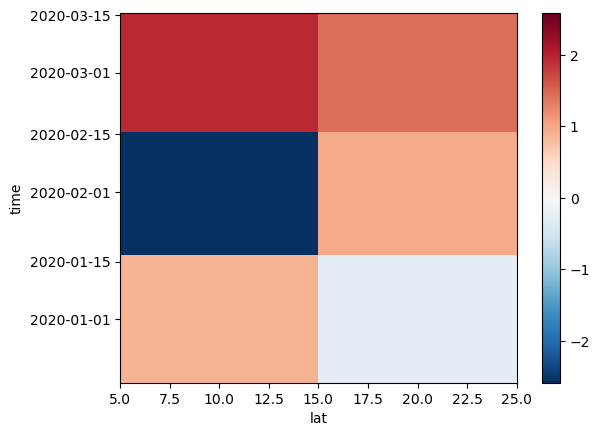

In [77]:
data = xr.DataArray(
    np.random.randn(3,2,3),
    dims = ("time", "lat", "lon"),
    coords = {
        "lat": [10,20],
        "time": pd.date_range(
            "2020-01", periods = 3, freq = "MS"
        ),
    },
)

data[0,:]
data.loc[:,10]
data.isel(lat=0)
data.sel(time="2020-01")
data.mean(dim=["time", "lat"])
data.isel(lon=0).plot();

In [78]:
import rasterio
import rasterio.features
import rasterio.warp

In [79]:
import sys
print(sys.executable)

/usr/local/Caskroom/mambaforge/base/bin/python3.10


In [80]:
with rasterio.open('/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif') as dataset:

    # Read the dataset's valid data mask as a ndarray.
    mask = dataset.dataset_mask()

    # Extract feature shapes and values from the array.
    for geom, val in rasterio.features.shapes(
            mask, transform=dataset.transform):

        # Transform shapes from the dataset's own coordinate
        # reference system to CRS84 (EPSG:4326).
        '''geom = rasterio.warp.transform_geom(
            dataset.crs, 'EPSG:4326', geom, precision=6)'''

        # Print GeoJSON shapes to stdout.
        print(dataset.crs)
        print(geom)

EPSG:4326
{'type': 'Polygon', 'coordinates': [[(-107.55192372387052, 33.89998227431894), (-107.55192372387052, 33.80215133817946), (-107.44588761244192, 33.80215133817946), (-107.44588761244192, 33.89998227431894), (-107.55192372387052, 33.89998227431894)]]}


In [81]:
dataset = rasterio.open('/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif')
dataset.name

'/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif'

In [6]:
#new_dataset = rasterio.open('/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif')
#new_dataset.name

'/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif'

In [82]:
dataset.count

1

In [83]:
dataset.width

168

In [84]:
dataset.height

155

In [85]:
dataset.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [86]:
from rasterio.transform import from_gcps
from rasterio.control import GroundControlPoint

In [87]:
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240406_ET.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    print(data)

[[      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 ...
 [      nan       nan       nan ... 152.39233 161.00047       nan]
 [      nan       nan       nan ... 144.40862 168.88841       nan]
 [      nan       nan       nan ... 139.04951 144.65076 166.00804]]


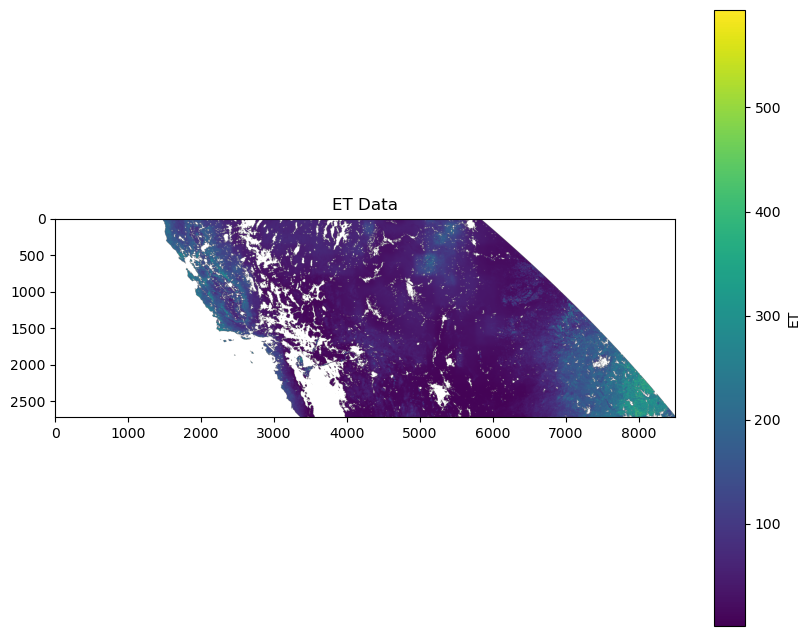

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [89]:
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    print(data)

[[      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 ...
 [      nan       nan       nan ... 405.08334 402.14795       nan]
 [      nan       nan       nan ... 402.9377  397.6011        nan]
 [      nan       nan       nan ... 403.94223 397.40744 402.252  ]]


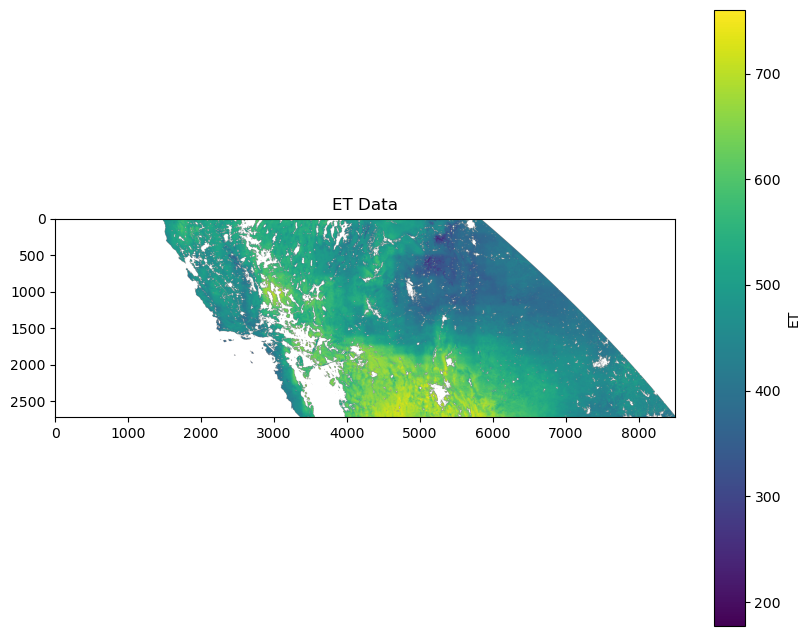

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [17]:
import os
all_files = os.listdir("/Users/ryanjoshi/Desktop/MODIS S3 downloads/")

monthly_files = []

for filename in all_files:
    if "202405" in filename and "_ET" in filename:
        monthly_files.append(filename)

monthly_files

#better to rely on some kind of reference -- load an image, get the dimensions of that image, and compare that to everything else
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"
with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    data *= 0.000001

for file in monthly_files:
    test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/" + file
    with rasterio.open(test_path) as src:
        data += src.read(1)
        data = np.where(data >= 32700, np.nan, data)
        #print(data)

data /= len(monthly_files)
print(data)


pet_files = []

for filename in all_files:
    if "202405" in filename and "PET" in filename:
        pet_files.append(filename)

test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"
with rasterio.open(test_path) as src:
    pet_data = src.read(1)
    pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
    pet_data *= 0.000001

for file in pet_files:
    test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/" + file
    with rasterio.open(test_path) as src:
        pet_data += src.read(1)
        pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
        #print(data)

pet_data /= len(pet_files)
print(pet_data)

#each ET or PET file is an 8 day average
esi_data = data/pet_data
esi_data = np.where(esi_data >= 0.1, np.nan, esi_data)
print(esi_data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(esi_data)
plt.colorbar(label='ESI')
plt.title('ESI Data')
plt.show()

ValueError: operands could not be broadcast together with shapes (2725,8496) (1526,1345) (2725,8496) 

In [91]:
import os
all_files = os.listdir("/Users/ryanjoshi/Desktop/MODIS S3 downloads/")
all_files += os.listdir("/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024")

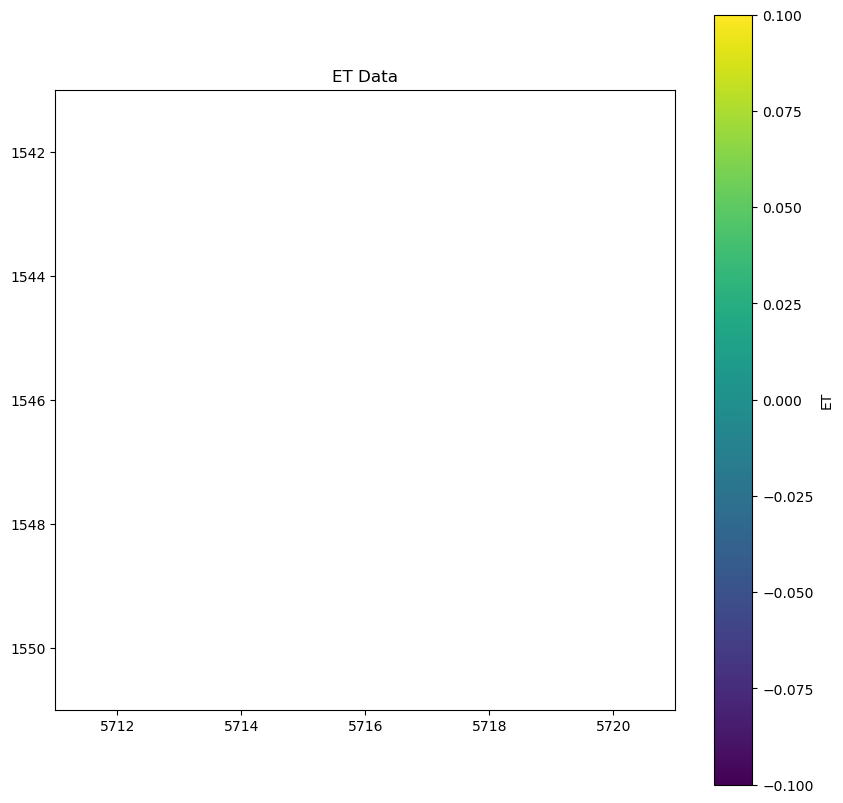

In [92]:
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data > 54.5, np.nan, data)
    data = np.where(data < 54.1, np.nan, data)
    #print(data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.xlim(5711,5721)
plt.ylim(1551,1541)
plt.show()

In [25]:
!pip install geopandas

In [93]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
from geodatasets import get_path

In [94]:
import xarray
import rioxarray
from affine import Affine

In [154]:
#%pip install xarray==2025.6.1

ERROR: Could not find a version that satisfies the requirement xarray==2025.6.1 (from versions: 0.7.0, 0.7.1, 0.7.2, 0.8.0rc1, 0.8.0, 0.8.1, 0.8.2, 0.9.0rc1, 0.9.0, 0.9.1, 0.9.2, 0.9.3, 0.9.4, 0.9.5, 0.9.6, 0.10.0rc1, 0.10.0rc2, 0.10.0, 0.10.1, 0.10.2, 0.10.3, 0.10.4, 0.10.5, 0.10.6, 0.10.7, 0.10.8, 0.10.9, 0.11.0, 0.11.1, 0.11.2, 0.11.3, 0.12.0, 0.12.1, 0.12.2, 0.12.3, 0.13.0, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.16.2, 0.17.0, 0.18.0, 0.18.1, 0.18.2, 0.19.0, 0.20.0, 0.20.1, 0.20.2, 0.21.0, 0.21.1, 2022.3.0, 2022.6.0rc0, 2022.6.0, 2022.9.0, 2022.10.0, 2022.11.0, 2022.12.0, 2023.1.0, 2023.2.0, 2023.3.0, 2023.4.0, 2023.4.1, 2023.4.2, 2023.5.0, 2023.6.0, 2023.7.0, 2023.8.0, 2023.9.0, 2023.10.0, 2023.10.1, 2023.11.0, 2023.12.0, 2024.1.0, 2024.1.1, 2024.2.0, 2024.3.0, 2024.5.0, 2024.6.0, 2024.7.0)
ERROR: No matching distribution found for xarray==2025.6.1
Note: you may need to restart the kernel to use updated packages.


In [95]:
#import xarray
xds = rioxarray.open_rasterio(
    "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif", 
    engine="rasterio")

In [158]:
#from affine import Affine

In [96]:
rds = rioxarray.open_rasterio("/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif", decode_coords="all")
rds.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]')

In [179]:
#import xarray as xr
#import gdal
print(rioxarray.__version__)

0.15.0


In [187]:
import pyproj
print(pyproj.__version__)

3.6.1


In [188]:
import pyproj
print(pyproj.__proj_version__)

9.3.0


In [97]:
import sys
print(sys.executable)

/usr/local/Caskroom/mambaforge/base/bin/python3.10


In [190]:
%pip install pyproj==3.7.1

ERROR: Could not find a version that satisfies the requirement pyproj==3.7.1 (from versions: 1.8.0, 1.8.1a0, 1.8.1, 1.9.3, 1.9.4, 1.9.5, 1.9.5.1, 1.9.6, 2.0.0, 2.0.1, 2.0.2, 2.1.0, 2.1.1, 2.1.2, 2.1.3, 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.4.2, 2.4.2.post1, 2.5.0, 2.6.0, 2.6.1, 2.6.1.post1, 3.0rc2, 3.0.0, 3.0.0.post1, 3.0.1, 3.1.0, 3.2.0, 3.2.1, 3.3.0, 3.3.1, 3.4.0rc1, 3.4.0rc2, 3.4.0, 3.4.1rc0, 3.4.1, 3.5.0rc0, 3.5.0, 3.6.0rc0, 3.6.0, 3.6.1rc0, 3.6.1)
ERROR: No matching distribution found for pyproj==3.7.1
Note: you may need to restart the kernel to use updated packages.


In [98]:
xda = xarray.DataArray(1)
xda.rio.write_crs(4326, inplace=True)
xda.spatial_ref

<xarray.DataArray 'spatial_ref' ()> Size: 8B
array(0)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    crs_wkt:                      GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...
    semi_major_axis:              6378137.0
    semi_minor_axis:              6356752.314245179
    inverse_flattening:           298.257223563
    reference_ellipsoid_name:     WGS 84
    longitude_of_prime_meridian:  0.0
    prime_meridian_name:          Greenwich
    geographic_crs_name:          WGS 84
    horizontal_datum_name:        World Geodetic System 1984
    grid_mapping_name:            latitude_longitude
    spatial_ref:                  GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...

In [99]:
xda.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [100]:
rds.rio.write_crs(4326, inplace=True)
#rds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
rds.rio.write_coordinate_system(inplace=True)

#rds = rds.rename(x="longitude", y="latitude")

#rds = rds.rio.reproject("EPSG:4326")

<xarray.DataArray (band: 1, y: 2725, x: 8496)> Size: 93MB
[23151600 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 68kB -1.453e+07 -1.453e+07 ... -1.028e+07
  * y            (y) float64 22kB 4.866e+06 4.865e+06 ... 3.504e+06 3.504e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     32700.0
    scale_factor:   1.0
    add_offset:     0.0

In [101]:
transform = Affine(3.0, 0.0, 466266.0, 0.0, -3.0, 8084700.0)
xda.rio.write_transform(transform, inplace=True)
xda.spatial_ref.GeoTransform

'466266.0 3.0 0.0 8084700.0 0.0 -3.0'

In [102]:
xda.rio.transform()

Affine(3.0, 0.0, 466266.0,
       0.0, -3.0, 8084700.0)

In [103]:
import urllib
import geojson

In [104]:
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.05, 36.999],
                 [-103, 36.999],
                [-103, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
cropped = xds.rio.clip(geometries=cropping_geometries, crs=4326)

In [44]:
import pyproj
print(pyproj.__proj_version__)

9.3.1


In [105]:
cropped

<xarray.DataArray (band: 1, y: 1526, x: 1347)> Size: 8MB
array([[[56.05772  , 56.702312 , 56.70582  , ..., 81.643105 ,
         81.7709   , 82.24886  ],
        [55.311386 , 55.770554 , 56.228333 , ..., 82.565765 ,
         82.62166  , 83.73735  ],
        [55.013046 , 55.254257 , 55.906826 , ..., 82.24882  ,
         82.425995 , 82.98256  ],
        ...,
        [13.702225 , 13.607969 , 14.792874 , ..., 15.7801075,
         17.137785 , 17.75787  ],
        [15.758725 , 14.838384 , 13.789731 , ..., 15.920914 ,
         17.08932  , 17.68497  ],
        [15.607399 , 17.527592 , 17.061396 , ..., 15.820736 ,
         17.021313 , 17.478968 ]]], shape=(1, 1526, 1347), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 11kB -1.214e+07 -1.214e+07 ... -1.147e+07
  * y            (y) float64 12kB 4.439e+06 4.438e+06 ... 3.677e+06 3.676e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     32700.0

In [106]:
def valid_imshow_data(data):
    data = np.asarray(data)
    if data.ndim == 2:
        return True
    elif data.ndim == 3:
        if 3 <= data.shape[2] <= 4:
            return True
        else:
            print('The "data" has 3 dimensions but the last dimension '
                  'must have a length of 3 (RGB) or 4 (RGBA), not "{}".'
                  ''.format(data.shape[2]))
            return False
    else:
        print('To visualize an image the data must be 2 dimensional or '
              '3 dimensional, not "{}".'
              ''.format(data.ndim))
        return False

valid_imshow_data(cropped)

cropped.ndim

The "data" has 3 dimensions but the last dimension must have a length of 3 (RGB) or 4 (RGBA), not "1347".


3

In [107]:
if cropped.shape[0] == 1:
    cropped = cropped[0, :, :]

cropped.ndim

2

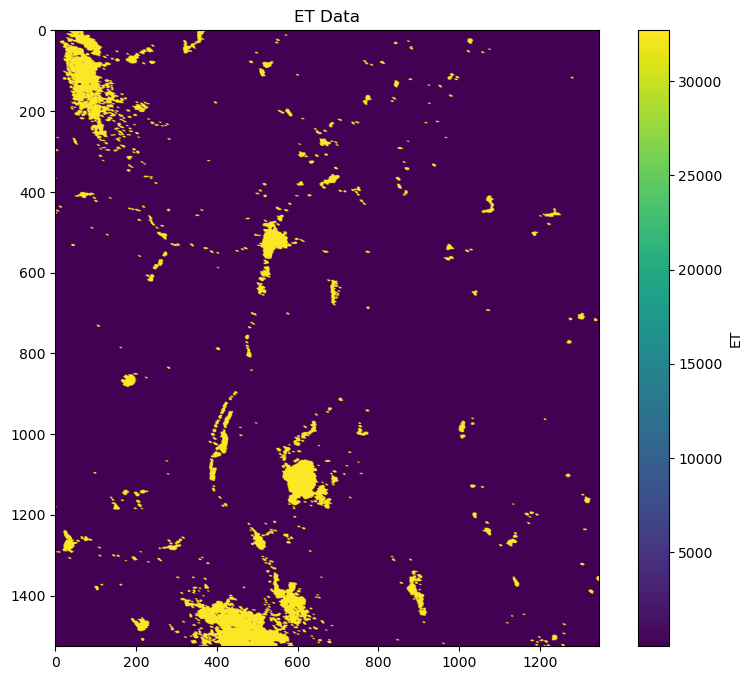

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(cropped)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [109]:
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-104.88, 34.45],
                [-104.84, 34.45],
                 [-104.84, 34.49],
                [-104.88, 34.49]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
beam = xds.rio.clip(geometries=cropping_geometries, crs=4326)

In [110]:
if beam.shape[0] == 1:
    beam = beam[0, :, :]

beam.ndim

2

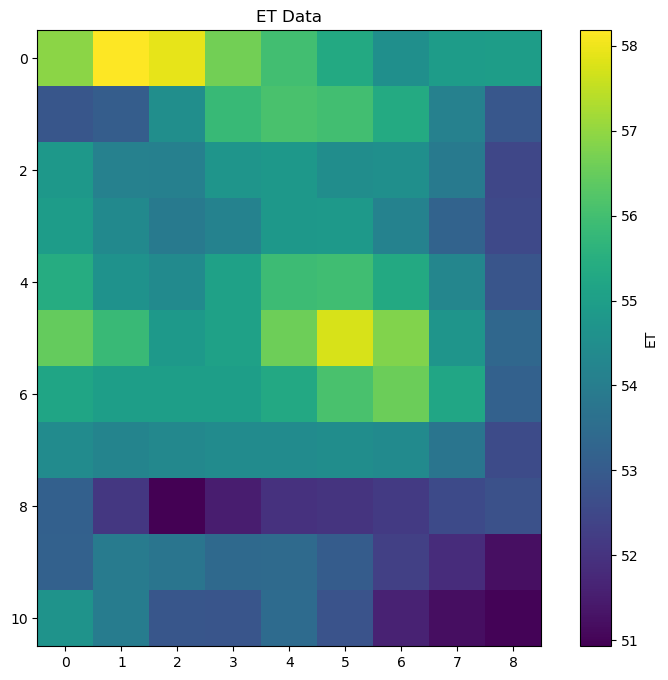

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(beam)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [112]:
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                 [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)

In [113]:
if new_mexico.shape[0] == 1:
    new_mexico = new_mexico[0, :, :]

new_mexico.ndim

2

In [114]:
new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

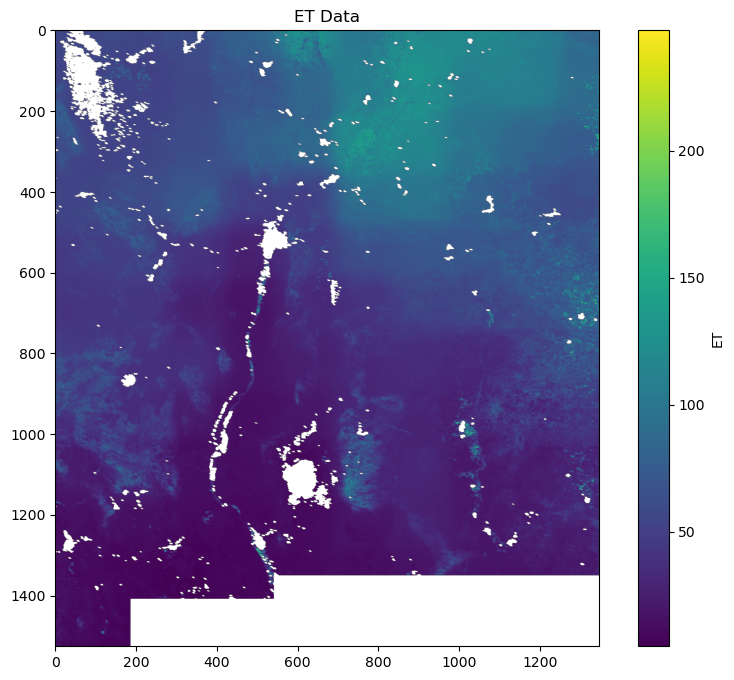

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [116]:
new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

Choose a year and month (format YYYYMM) 202309


['MOD16A2_MERGED_20230922_ET.tif', 'MOD16A2_MERGED_20230930_ET.tif', 'MOD16A2_MERGED_20230906_ET.tif', 'MOD16A2_MERGED_20230914_ET.tif']


Choose an ET threshold (I would recommend a threshold between 50 and 150) 100


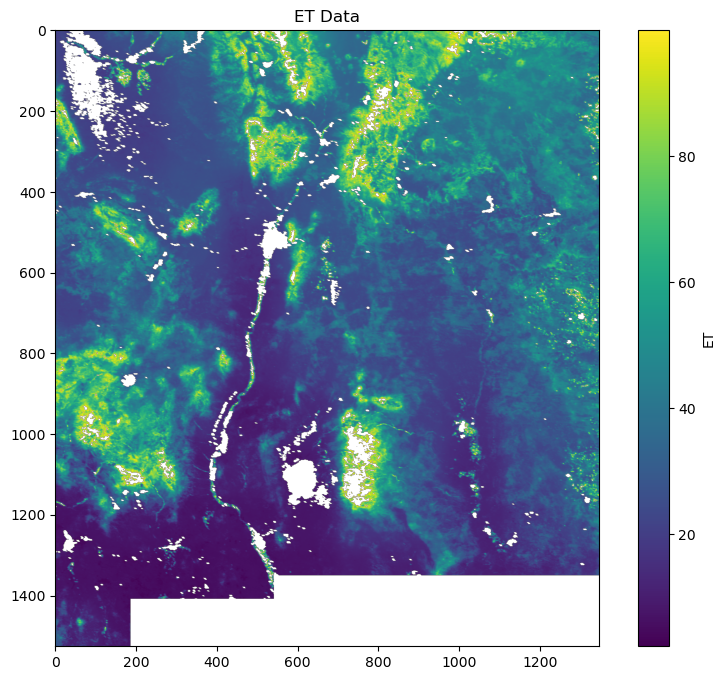

In [117]:
# monthly average
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]
new_mexico = new_mexico * 0.00000001

monthly_files = []

month = int(input("Choose a year and month (format YYYYMM)"))
str_month = str(month)

for filename in all_files:
    if str_month in filename and "_ET" in filename and "MERGED" in filename:
        monthly_files.append(filename)

print(monthly_files)

for file in monthly_files:
    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/' + file)
    new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico_2 = new_mexico_2[0, :, :]
    new_mexico += new_mexico_2

new_mexico /= len(monthly_files)
#print(new_mexico)

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
threshold = int(input("Choose an ET threshold (I would recommend a threshold between 50 and 150)"))
new_mexico = np.where(new_mexico >= threshold, np.nan, new_mexico)

'''pet_files = []

for filename in all_files:
    if "202405" in filename and "PET" in filename:
        pet_files.append(filename)

pet_data = np.zeros((2725, 8496))

for file in pet_files:
    test_path = "/Applications/MODIS_S3_downloads/" + file
    with rasterio.open(test_path) as src:
        pet_data += src.read(1)
        pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
        #print(data)

pet_data /= len(pet_files)
print(pet_data)'''

#each ET or PET file is an 8 day average
'''esi_data = data/pet_data
esi_data = np.where(esi_data >= 0.1, np.nan, esi_data)
print(esi_data)'''

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

Choose a western boundary -104.31
Choose a southern boundary 33.7
Choose a eastern boundary -104.16
Choose a northern boundary 33.85


 {"type": "Polygon",
               "coordinates": [
                [[-104.31, 33.7],
                [-104.31, 33.85],
                [-104.16, 33.85],
                [-104.16, 33.7]]]}


Choose a year and month (format YYYYMM) 202309
Choose an minimum ET threshold (type 0 if N/A) 0
Choose an maximum ET threshold (type 32700 if N/A) 100


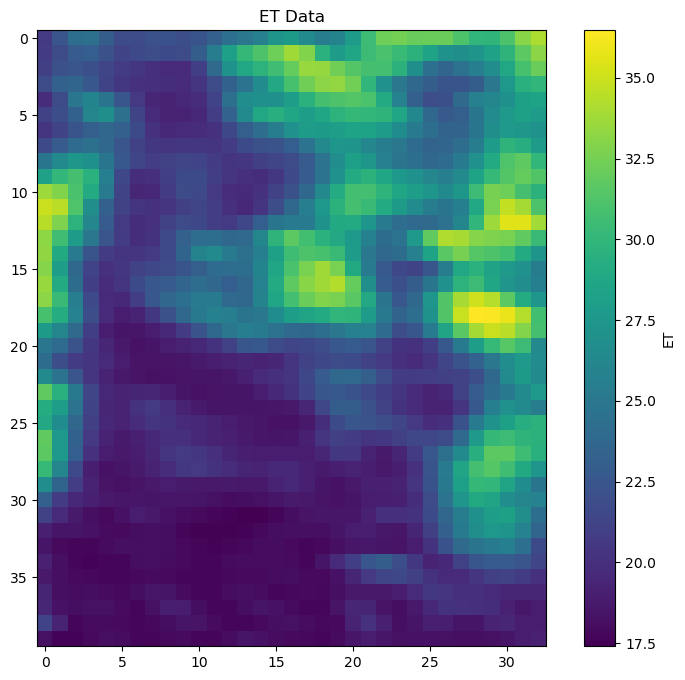

In [118]:
# monthly average with coordinate choices

coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''
print(geometry)

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]
new_mexico = new_mexico * 0.00000001

monthly_files = []

month = int(input("Choose a year and month (format YYYYMM)"))
str_month = str(month)

for filename in all_files:
    if str_month in filename and "_ET" in filename and "MERGED" in filename:
        monthly_files.append(filename)

monthly_files

for file in monthly_files:
    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/' + file)
    new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico_2 = new_mexico_2[0, :, :]
    new_mexico += new_mexico_2

new_mexico /= len(monthly_files)
#print(new_mexico)

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = int(input("Choose an minimum ET threshold (type 0 if N/A)"))
max_threshold = int(input("Choose an maximum ET threshold (type 32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

'''pet_files = []

for filename in all_files:
    if "202405" in filename and "PET" in filename:
        pet_files.append(filename)

pet_data = np.zeros((2725, 8496))

for file in pet_files:
    test_path = "/Applications/MODIS_S3_downloads/" + file
    with rasterio.open(test_path) as src:
        pet_data += src.read(1)
        pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
        #print(data)

pet_data /= len(pet_files)
print(pet_data)'''

#each ET or PET file is an 8 day average
'''esi_data = data/pet_data
esi_data = np.where(esi_data >= 0.1, np.nan, esi_data)
print(esi_data)'''

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

Choose a western boundary -104.31
Choose a southern boundary 33.7
Choose a eastern boundary -104.16
Choose a northern boundary 33.85
Choose an minimum ET threshold (0 if N/A) 0
Choose an maximum ET threshold (32700 if N/A) 100


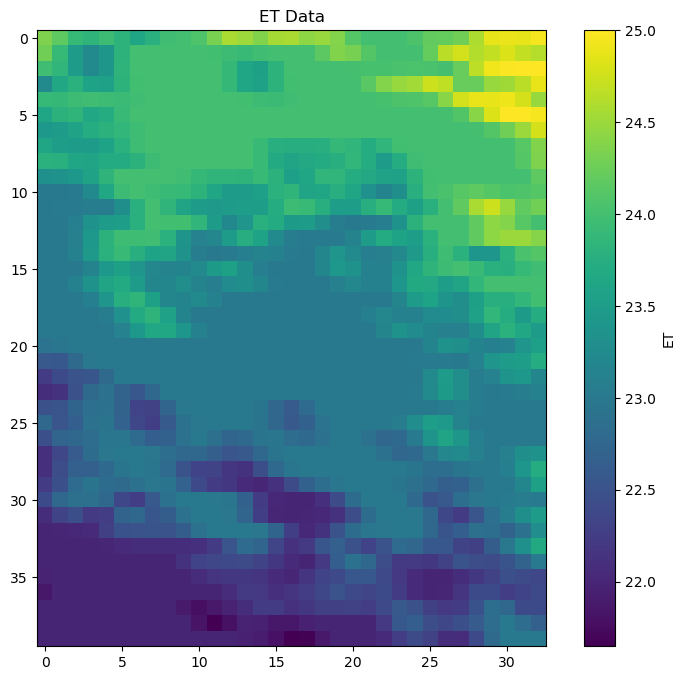

In [119]:
#test coordinate algorithm for single TIF file to ensure it matches QGIS

coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20241210_ET.tif')
#xds.rio.write_crs(4326, inplace=True)
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = float(input("Choose an minimum ET threshold (0 if N/A)"))
max_threshold = float(input("Choose an maximum ET threshold (32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

[[nan nan nan ... 41. 41. 42.]
 [nan nan nan ... 41. 41. 42.]
 [nan nan nan ... 42. 41. nan]
 ...
 [nan 54. 56. ... nan nan nan]
 [nan 55. 55. ... nan nan nan]
 [58. 55. 56. ... nan nan nan]]


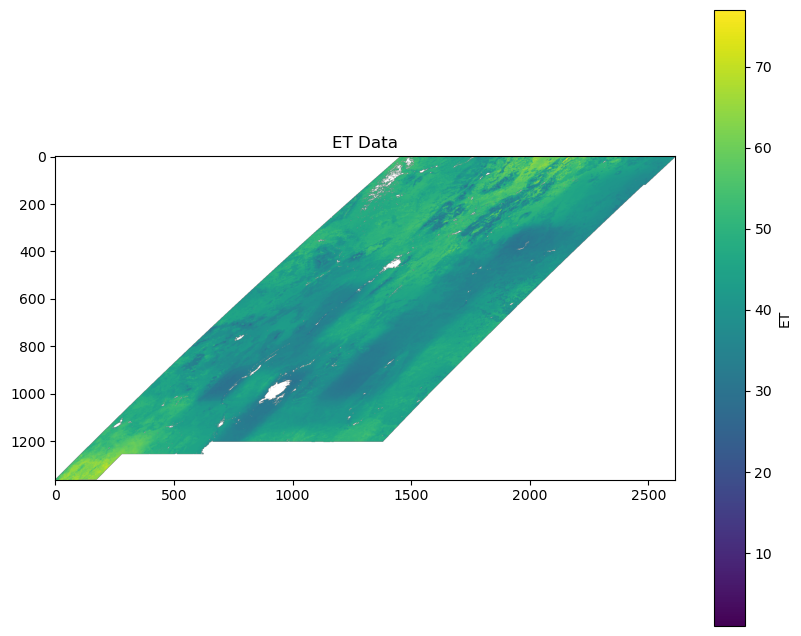

In [120]:
test_path = "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2004361000000_aid0001.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    print(data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

Choose a western boundary -104.31
Choose a southern boundary 33.7
Choose a eastern boundary -104.16
Choose a northern boundary 33.85
Choose an minimum ET threshold (0 if N/A) 0
Choose an maximum ET threshold (32700 if N/A) 100


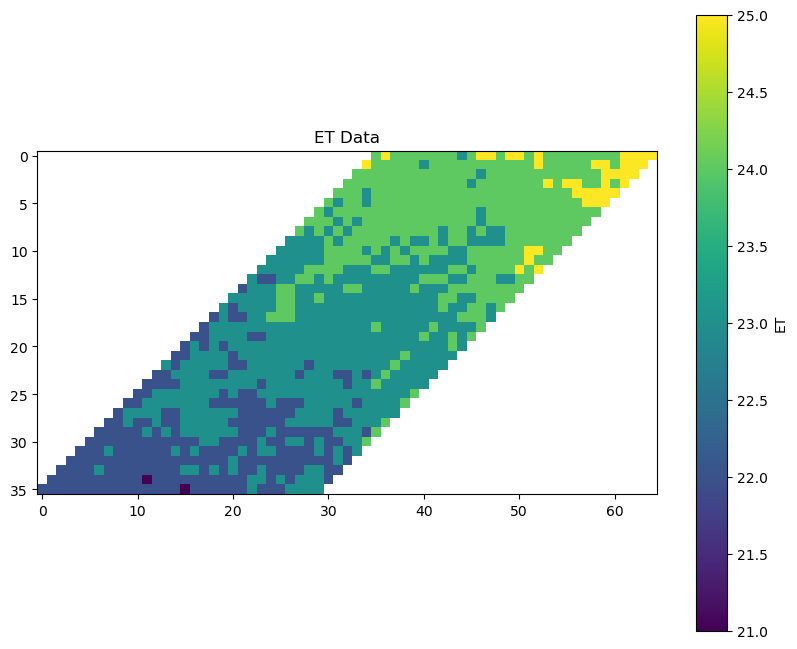

In [121]:
#test coordinate algorithm for single TIF file to ensure it matches QGIS

coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024345000000_aid0001.tif')
#xds.rio.write_crs(4326, inplace=True)
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = float(input("Choose an minimum ET threshold (0 if N/A)"))
max_threshold = float(input("Choose an maximum ET threshold (32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

Choose a western boundary -104.31
Choose a southern boundary 33.7
Choose a eastern boundary -104.16
Choose a northern boundary 33.85
Choose an minimum ET threshold (0 if N/A) 0
Choose an maximum ET threshold (32700 if N/A) 100


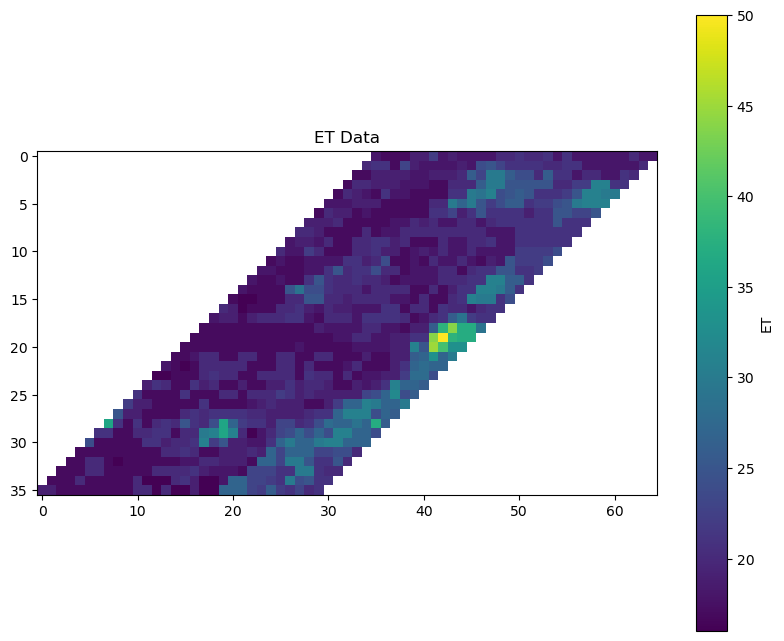

In [122]:
coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2005089000000_aid0001.tif')
#xds.rio.write_crs(4326, inplace=True)
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = float(input("Choose an minimum ET threshold (0 if N/A)"))
max_threshold = float(input("Choose an maximum ET threshold (32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [123]:

import datetime
from datetime import date, timedelta

In [152]:
class DroughtDetection:
    def __init__(
            self, 
            geojson_file: str,
            date: datetime.date
    ):
        
        self.geojson_file = geojson_file #base of constructor
        self.date = date #base of constructor

    def generate_tiffs(self, start, end):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif'))

        current_date = date.today()
        start_date = current_date - timedelta(days=start) 

        while start_date <= current_date - timedelta(days=end):
            string_date = str(start_date)
            string_date = string_date.replace("-", "")
            check_for_tiff(string_date)
            start_date += timedelta(days=1)

        return list_of_tiffs

    def generate_static_tiffs(self, start_year, start_month, start_day, end_year, end_month, end_day):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif'))

        #current_date = date.today()
        start_date = date(start_year, start_month, start_day)
        end = date(end_year, end_month, end_day)

        while start_date <= end:
            string_date = str(start_date)
            string_date = string_date.replace("-", "")
            check_for_tiff(string_date)
            start_date += timedelta(days=1)
            
        return list_of_tiffs

    def generate_et_tiffs(self, start_year, start_month, start_day, end_year, end_month, end_day):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))

        def find_doy(date):
            date = date.replace("-", "")
            if date[4:6] == "01":
                day = int(date[6:8])
                if day<10:
                    date = date.replace(date[4:8], "00" + str(day))
                else:
                    date = date.replace(date[4:8], "0" + str(day))
            elif date[4:6] == "02":
                day = int(date[6:8])
                num = 31 + day
                date = date.replace(date[4:8], "0" + str(num))
            elif date[4:6] == "03":
                day = int(date[6:8])
                num = 59 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], "0" + str(num))
            elif date[4:6] == "04":
                day = int(date[6:8])
                num = 90 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                if num<100:
                    date = date.replace(date[4:8], "0" + str(num))
                else:
                    date = date.replace(date[4:8], str(num))
            elif date[4:6] == "05":
                day = int(date[6:8])
                num = 120 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "06":
                day = int(date[6:8])
                num = 151 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "07":
                day = int(date[6:8])
                num = 181 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "08":
                day = int(date[6:8])
                num = 212 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "09":
                day = int(date[6:8])
                num = 243 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "10":
                day = int(date[6:8])
                num = 273 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "11":
                day = int(date[6:8])
                num = 304 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "12":
                day = int(date[6:8])
                num = 334 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            else:
                print("Invalid date.")
            return date

        #new_date = date(year, month, day)
        #new_date = str(new_date)
        #new_date = find_doy(new_date)
        #check_for_tiff(new_date)

        start_date = date(start_year, start_month, start_day)
        end = date(end_year, end_month, end_day)

        while start_date <= end:
            string_date = str(start_date)
            string_date = find_doy(string_date)
            check_for_tiff(string_date)
            start_date += timedelta(days=1)

        return list_of_tiffs

    def find_stdev(self, start_year, start_month, start_day, end_year, end_month, end_day):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))
    
        #current_date = date.today()
        start_date = date(start_year, start_month, start_day)
        end = date(end_year, end_month, end_day)

        while start_date <= end:
            string_date = str(start_date)
            string_date = find_doy(string_date)
            string_date = string_date.replace("-", "")
            check_for_tiff(string_date)
            start_date += timedelta(days=1)

        #print(list_of_tiffs)

        tiff_data = []

        def get_tiff_data(tiff):
            xds = rioxarray.open_rasterio(tiff)
            tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
            tiff = tiff[0, :, :]
            #tiff = np.where(tiff >= 32700, np.nan, tiff)
            return tiff

        for tiff in list_of_tiffs:
            #print(np.shape(tiff))
            tiff_data.append(get_tiff_data(tiff))
            #tiff = np.where(tiff >= 32700, np.nan, tiff)

        #print(tiff_data)

        sd = tiff_data[0] * 0.0000001
        sum_sq = (tiff_data[0]) * 0.0000001
        sum_reg = tiff_data[0] * 0.0000001

        for tiff in tiff_data:   
            sum_reg += tiff
        
        mean = sum_reg/len(tiff_data)
    
        for tiff in tiff_data:
            sum_sq += (tiff-mean)**2

        #print(sum_sq)
    
        sd = ((sum_sq)/(len(tiff_data)-1))**0.5
        #print(sd)

        sd = np.where(sd < 1, np.nan, sd)

        import matplotlib.pyplot as plt
    
        plt.figure(figsize=(10,8))
        plt.imshow(sd)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

    def choose_coordinates(self, coord1, coord2, coord3, coord4):
        geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + str(coord1) + ''', ''' + str(coord2) + '''],
                [''' + str(coord1) + ''', ''' + str(coord4) + '''],
                [''' + str(coord3) + ''', ''' + str(coord4) + '''],
                [''' + str(coord3) + ''', ''' + str(coord2) + ']]]}'''
        return geometry

    def generate_threshold(self, list_of_tiffs, low, high):
        #return threshold #get this code to run in jupyter notebook
        geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

        cropping_geometries = [geojson.loads(geometry)]

        xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
        new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico = new_mexico[0, :, :]
        new_mexico = new_mexico * 0.00000001

        for tiff in list_of_tiffs:
            xds = rioxarray.open_rasterio(tiff)
            new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
            new_mexico_2 = new_mexico_2[0, :, :]
            new_mexico += new_mexico_2

        new_mexico /= len(monthly_files)
            #print(new_mexico)

        new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
        new_mexico = np.where(new_mexico < low, np.nan, new_mexico)
        new_mexico = np.where(new_mexico > high, np.nan, new_mexico)

        plt.figure(figsize=(10,8))
        plt.imshow(new_mexico)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

    def generate_threshold_coords(self, coords, list_of_tiffs, low, high):
        #return threshold #get this code to run in jupyter notebook
        geometry = coords

        cropping_geometries = [geojson.loads(geometry)]

        xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
        #xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024321000000_aid0001.tif')
        new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico = new_mexico[0, :, :]
        new_mexico = new_mexico * 0.00000001

        for tiff in list_of_tiffs:
            xds = rioxarray.open_rasterio(tiff)
            new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
            new_mexico_2 = new_mexico_2[0, :, :]
            new_mexico += new_mexico_2

        new_mexico /= len(monthly_files)
            #print(new_mexico)

        new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
        new_mexico = np.where(new_mexico < low, np.nan, new_mexico)
        new_mexico = np.where(new_mexico > high, np.nan, new_mexico)

        plt.figure(figsize=(10,8))
        plt.imshow(new_mexico)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

    def generate_threshold_modis(self, coords, list_of_tiffs, low, high):
        #return threshold #get this code to run in jupyter notebook
        geometry = coords

        cropping_geometries = [geojson.loads(geometry)]

        #xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
        xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2005089000000_aid0001.tif')
        new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico = new_mexico[0, :, :]
        new_mexico = new_mexico * 0.00000001

        for tiff in list_of_tiffs:
            xds = rioxarray.open_rasterio(tiff)
            new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
            new_mexico_2 = new_mexico_2[0, :, :]
            new_mexico += new_mexico_2

        new_mexico /= len(list_of_tiffs)
            #print(new_mexico)

        new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
        new_mexico = np.where(new_mexico < low, np.nan, new_mexico)
        new_mexico = np.where(new_mexico > high, np.nan, new_mexico)

        plt.figure(figsize=(10,8))
        plt.imshow(new_mexico)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

In [153]:
import datetime

model = DroughtDetection(
    geojson_file = "path/to/geojson",
    date = datetime.datetime.now()
)

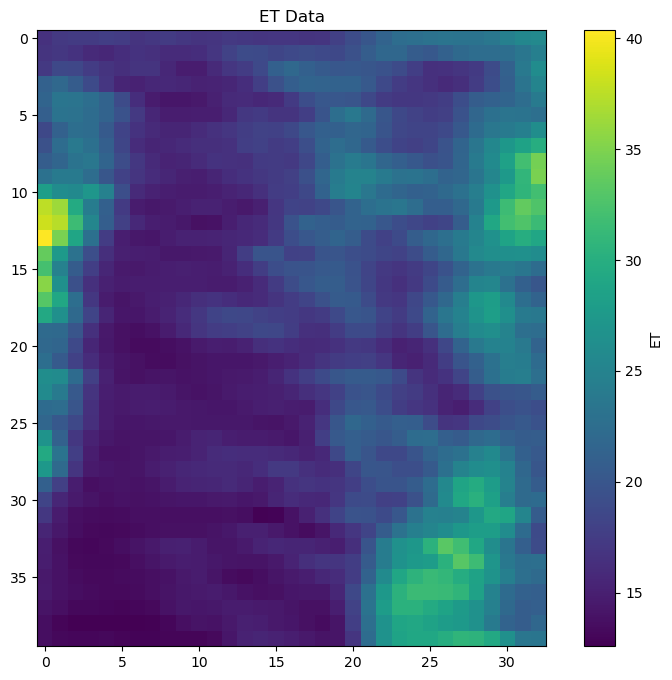

['/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240617_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240625_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240703_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240711_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240719_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240727_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240804_ET.tif']
 {"type": "Polygon",
               "coordinates": [
                [[-104.31, 33.7],
                [-104.31, 33.85],
                [-104.16, 33.85],
                [-104.16, 33.7]]]}


In [142]:
list_of_tiffs = model.generate_static_tiffs(2024, 6, 17, 2024, 8, 4)
#list_of_tiffs = model.generate_tiffs(390, 340)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
model.generate_threshold_coords(coords, list_of_tiffs, 0, 100)
print(list_of_tiffs)
print(coords)

['/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2019073000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2019081000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2019089000000_aid0001.tif']
 {"type": "Polygon",
               "coordinates": [
                [[-104.31, 33.7],
                [-104.31, 33.85],
                [-104.16, 33.85],
                [-104.16, 33.7]]]}


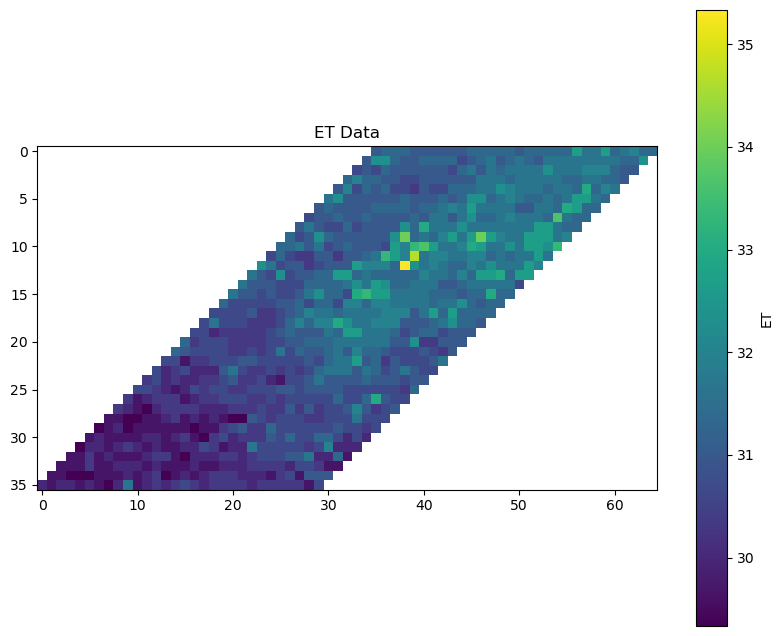

In [154]:
list_of_tiffs = model.generate_et_tiffs(2019, 3, 8, 2019, 4, 5)
#list_of_tiffs += model.generate_et_tiffs(2020, 3, 8, 2020, 4, 5)
print(list_of_tiffs)
#list_of_tiffs = model.generate_tiffs(390, 340)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
print(coords)
model.generate_threshold_modis(coords, list_of_tiffs, 0, 100)
#print(list_of_tiffs)

In [54]:
current_date = date.today() - timedelta(days=144)

current_date = str(current_date)

def find_doy(date):
    date = date.replace("-", "")
    if date[4:6] == "01":
        day = int(date[6:8])
        if day<10:
            date = date.replace(date[4:8], "00" + str(day))
        else:
            date = date.replace(date[4:8], "0" + str(day))
    elif date[4:6] == "02":
        day = int(date[6:8])
        num = 31 + day
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "03":
        day = int(date[6:8])
        num = 59 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "04":
        day = int(date[6:8])
        num = 90 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        if num<100:
            date = date.replace(date[4:8], "0" + str(num))
        else:
            date = date.replace(date[4:8], str(num))
    elif date[4:6] == "05":
        day = int(date[6:8])
        num = 120 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "06":
        day = int(date[6:8])
        num = 151 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "07":
        day = int(date[6:8])
        num = 181 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "08":
        day = int(date[6:8])
        num = 212 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "09":
        day = int(date[6:8])
        num = 243 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "10":
        day = int(date[6:8])
        num = 273 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "11":
        day = int(date[6:8])
        num = 304 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "12":
        day = int(date[6:8])
        num = 334 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    else:
        print("Invalid date.")
    return date

find_doy("2024-07-31")

'2024213'

In [100]:
start_date = date(2024,10,21)
end = date(2024,11,16)

while start_date <= end:
    string_date = str(start_date)
    #string_date = find_doy(string_date)
    #check_for_tiff(string_date)
    start_date += timedelta(days=1)
    print(start_date)

2024-10-22
2024-10-23
2024-10-24
2024-10-25
2024-10-26
2024-10-27
2024-10-28
2024-10-29
2024-10-30
2024-10-31
2024-11-01
2024-11-02
2024-11-03
2024-11-04
2024-11-05
2024-11-06
2024-11-07
2024-11-08
2024-11-09
2024-11-10
2024-11-11
2024-11-12
2024-11-13
2024-11-14
2024-11-15
2024-11-16
2024-11-17


In [155]:
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                 [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

#cropping_geometries = [geojson.loads(geometry)]
#xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024305000000_aid0001.tif')
#new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)

'''if new_mexico.shape[0] == 1:
    new_mexico = new_mexico[0, :, :]
new_mexico.ndim
new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024313000000_aid0001.tif')
nm_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)

if nm_2.shape[0] == 1:
    nm_2 = nm_2[0, :, :]
nm_2.ndim
nm_2 = np.where(nm_2 >= 32700, np.nan, nm_2)

nm_3 = (new_mexico + nm_2)/2
sd = (new_mexico-nm_3)**2 + (nm_2-nm_3)**2
sd = sd**0.5

print(new_mexico)
print(nm_2)
print(nm_3)
print(sd)'''

def find_doy(date):
    date = date.replace("-", "")
    if date[4:6] == "01":
        day = int(date[6:8])
        if day<10:
            date = date.replace(date[4:8], "00" + str(day))
        else:
            date = date.replace(date[4:8], "0" + str(day))
    elif date[4:6] == "02":
        day = int(date[6:8])
        num = 31 + day
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "03":
        day = int(date[6:8])
        num = 59 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "04":
        day = int(date[6:8])
        num = 90 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        if num<100:
            date = date.replace(date[4:8], "0" + str(num))
        else:
            date = date.replace(date[4:8], str(num))
    elif date[4:6] == "05":
        day = int(date[6:8])
        num = 120 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "06":
        day = int(date[6:8])
        num = 151 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "07":
        day = int(date[6:8])
        num = 181 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "08":
        day = int(date[6:8])
        num = 212 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "09":
        day = int(date[6:8])
        num = 243 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "10":
        day = int(date[6:8])
        num = 273 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "11":
        day = int(date[6:8])
        num = 304 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "12":
        day = int(date[6:8])
        num = 334 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    else:
        print("Invalid date.")
    return date

def find_sd(start_year, start_month, start_day, end_year, end_month, end_day):
    from rasterio import shutil

    list_of_tiffs = []

    def check_for_tiff(date):
        #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
            list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))
    
    #current_date = date.today()
    start_date = date(start_year, start_month, start_day)
    end = date(end_year, end_month, end_day)

    while start_date <= end:
        string_date = str(start_date)
        string_date = find_doy(string_date)
        string_date = string_date.replace("-", "")
        check_for_tiff(string_date)
        start_date += timedelta(days=1)

    print(list_of_tiffs)

    tiff_data = []

    def get_tiff_data(tiff):
        xds = rioxarray.open_rasterio(tiff)
        tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        tiff = tiff[0, :, :]
        tiff = np.where(tiff >= 32700, np.nan, tiff)
        return tiff

    for tiff in list_of_tiffs:
        #print(np.shape(tiff))
        tiff_data.append(get_tiff_data(tiff))
        #tiff = np.where(tiff >= 32700, np.nan, tiff)

    print(tiff_data)

    sd = tiff_data[0] * 0.0000001
    sum_sq = (tiff_data[0]) * 0.0000001
    sum_reg = tiff_data[0] * 0.0000001

    for tiff in tiff_data:   
        sum_reg += tiff
        
    mean = sum_reg/len(tiff_data)
    
    for tiff in tiff_data:
        sum_sq += (tiff-mean)**2

    print(sum_sq)
    
    sd = ((sum_sq)/(len(tiff_data)-1))**0.5
    print(sd)

    sd = np.where(sd < 1, np.nan, sd)

    #return sd

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10,8))
    plt.imshow(sd)
    plt.colorbar(label='ET')
    plt.title('ET Data')
    return plt.show()

find_sd(2024, 1, 1, 2024, 12, 31)

['/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024001000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024009000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024017000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024025000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024033000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024041000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024049000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024057000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024065000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_

NoDataInBounds: No data found in bounds.

In [ ]:
list_of_tiffs = model.generate_et_tiffs(2002, 7, 31, 2024, 11, 5)
#print(list_of_tiffs)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
et_map = model.generate_threshold_modis(coords, list_of_tiffs, 0, 10000)
et_map

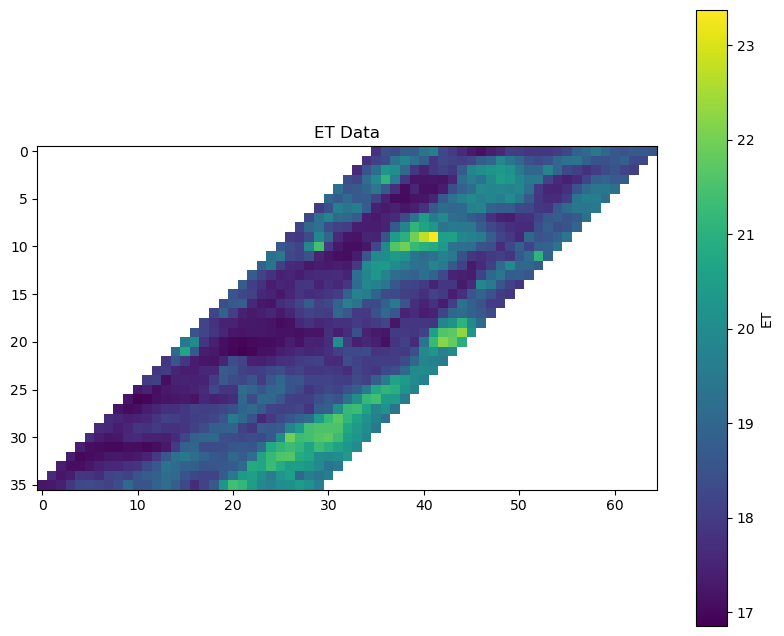

In [127]:
et_stdev = model.find_stdev(2002, 7, 31, 2024, 11, 5)
et_stdev

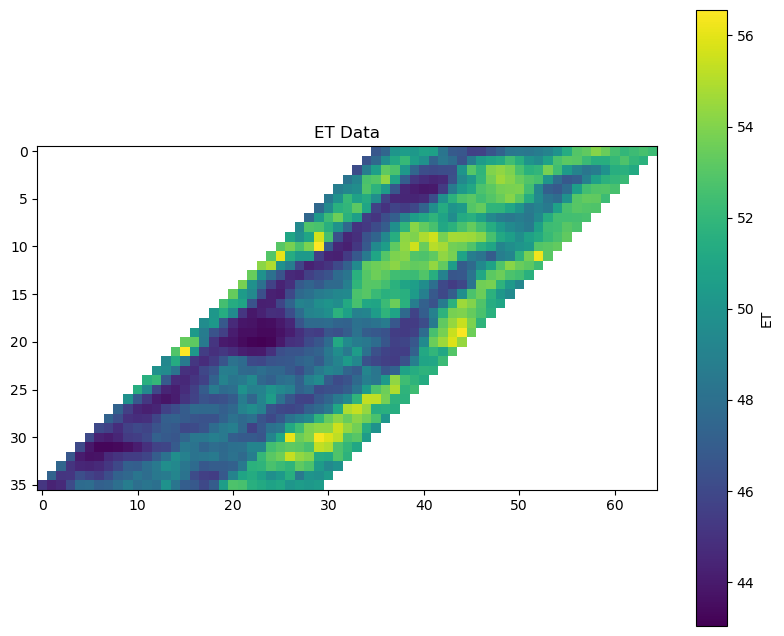

In [132]:
def find_sd_plus(start_year, start_month, start_day, end_year, end_month, end_day):
    from rasterio import shutil

    list_of_tiffs = []

    def check_for_tiff(date):
        #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
            list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))
    
    #current_date = date.today()
    start_date = date(start_year, start_month, start_day)
    end = date(end_year, end_month, end_day)

    while start_date <= end:
        string_date = str(start_date)
        string_date = find_doy(string_date)
        string_date = string_date.replace("-", "")
        check_for_tiff(string_date)
        start_date += timedelta(days=1)

    #print(list_of_tiffs)

    tiff_data = []

    def get_tiff_data(tiff):
        xds = rioxarray.open_rasterio(tiff)
        tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        tiff = tiff[0, :, :]
        tiff = np.where(tiff >= 32700, np.nan, tiff)
        return tiff

    for tiff in list_of_tiffs:
        #print(np.shape(tiff))
        tiff_data.append(get_tiff_data(tiff))
        #tiff = np.where(tiff >= 32700, np.nan, tiff)

    #print(tiff_data)

    sd = tiff_data[0] * 0.0000001
    sum_sq = (tiff_data[0]) * 0.0000001
    sum_reg = tiff_data[0] * 0.0000001

    for tiff in tiff_data:   
        sum_reg += tiff
        
    mean = sum_reg/len(tiff_data)
    
    for tiff in tiff_data:
        sum_sq += (tiff-mean)**2

    #print(sum_sq)
    
    sd = ((sum_sq)/(len(tiff_data)-1))**0.5
    #print(sd)

    sd = np.where(sd < 1, np.nan, sd)

    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024321000000_aid0001.tif')
    new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico = new_mexico[0, :, :]
    new_mexico = new_mexico * 0.00000001

    for tiff in list_of_tiffs:
        xds = rioxarray.open_rasterio(tiff)
        new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico_2 = new_mexico_2[0, :, :]
        new_mexico += new_mexico_2

    new_mexico /= len(list_of_tiffs)
    
    new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

    sd += new_mexico

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10,8))
    plt.imshow(sd)
    plt.colorbar(label='ET')
    plt.title('ET Data')
    return plt.show()

find_sd_plus(2002, 7, 31, 2024, 11, 5)

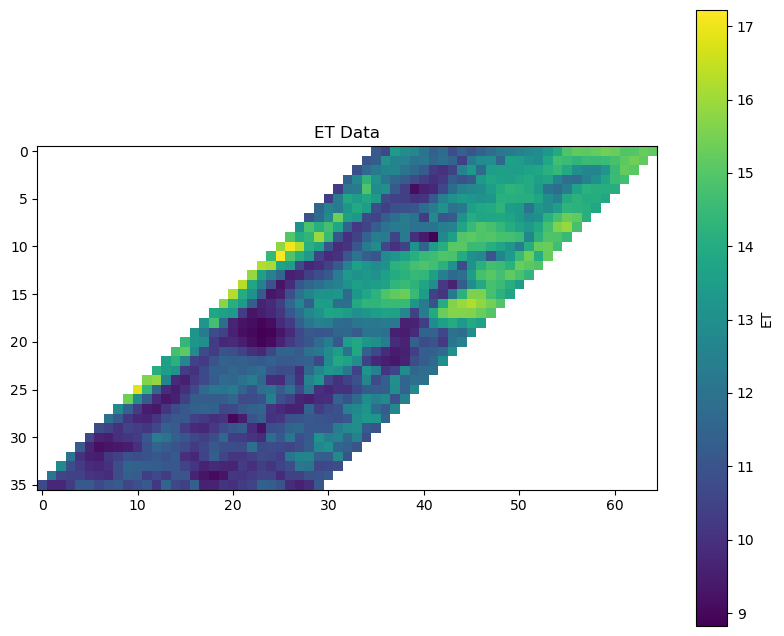

In [133]:
def find_sd_minus(start_year, start_month, start_day, end_year, end_month, end_day):
    from rasterio import shutil

    list_of_tiffs = []

    def check_for_tiff(date):
        #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
            list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))
    
    #current_date = date.today()
    start_date = date(start_year, start_month, start_day)
    end = date(end_year, end_month, end_day)

    while start_date <= end:
        string_date = str(start_date)
        string_date = find_doy(string_date)
        string_date = string_date.replace("-", "")
        check_for_tiff(string_date)
        start_date += timedelta(days=1)

    #print(list_of_tiffs)

    tiff_data = []

    def get_tiff_data(tiff):
        xds = rioxarray.open_rasterio(tiff)
        tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        tiff = tiff[0, :, :]
        tiff = np.where(tiff >= 32700, np.nan, tiff)
        return tiff

    for tiff in list_of_tiffs:
        #print(np.shape(tiff))
        tiff_data.append(get_tiff_data(tiff))
        #tiff = np.where(tiff >= 32700, np.nan, tiff)

    #print(tiff_data)

    sd = tiff_data[0] * 0.0000001
    sum_sq = (tiff_data[0]) * 0.0000001
    sum_reg = tiff_data[0] * 0.0000001

    for tiff in tiff_data:   
        sum_reg += tiff
        
    mean = sum_reg/len(tiff_data)
    
    for tiff in tiff_data:
        sum_sq += (tiff-mean)**2

    #print(sum_sq)
    
    sd = ((sum_sq)/(len(tiff_data)-1))**0.5
    #print(sd)

    sd = np.where(sd < 1, np.nan, sd)

    sd *= -1

    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024321000000_aid0001.tif')
    new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico = new_mexico[0, :, :]
    new_mexico = new_mexico * 0.00000001

    for tiff in list_of_tiffs:
        xds = rioxarray.open_rasterio(tiff)
        new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico_2 = new_mexico_2[0, :, :]
        new_mexico += new_mexico_2

    new_mexico /= len(list_of_tiffs)
    
    new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

    sd += new_mexico

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10,8))
    plt.imshow(sd)
    plt.colorbar(label='ET')
    plt.title('ET Data')
    return plt.show()

find_sd_minus(2002, 7, 31, 2024, 11, 5)

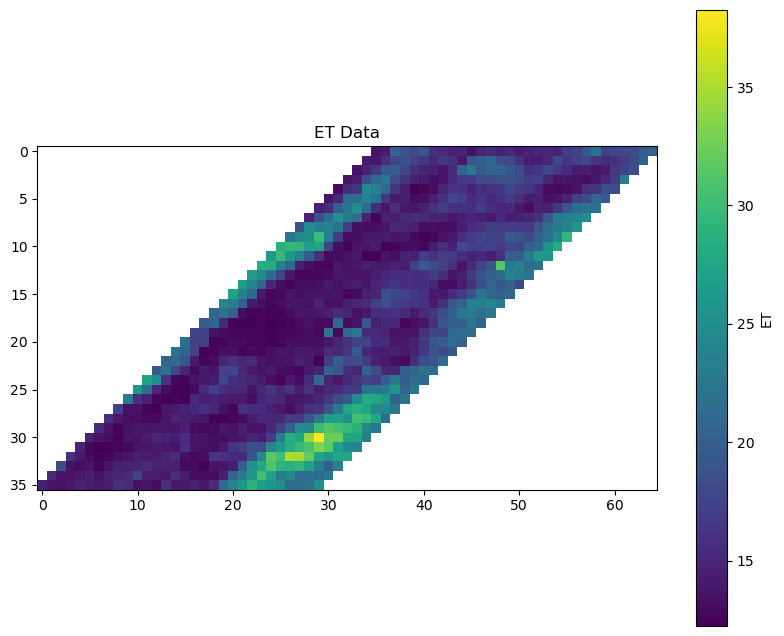

In [156]:
list_of_tiffs = model.generate_et_tiffs(2024, 7, 31, 2024, 11, 5)
#print(list_of_tiffs)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
et_map_2024 = model.generate_threshold_modis(coords, list_of_tiffs, 0, 10000)
et_map_2024

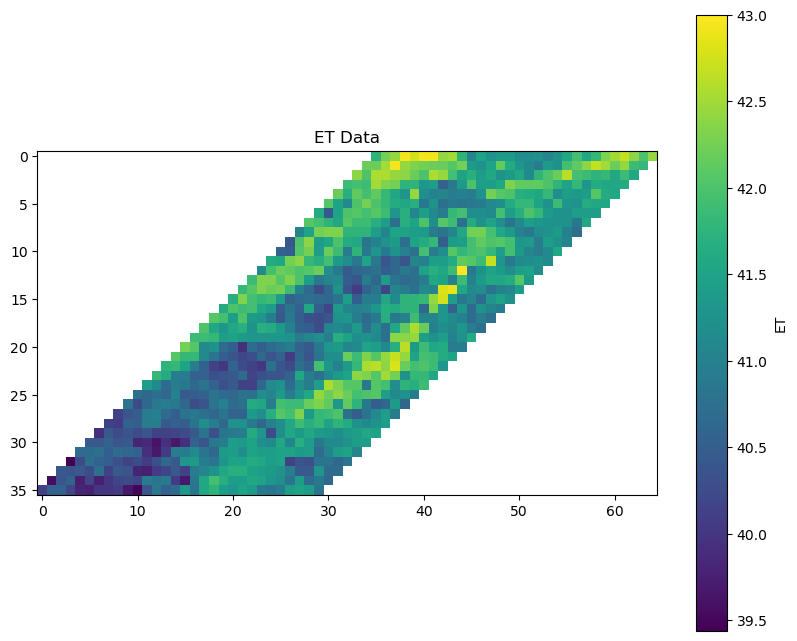

NameError: name 'your_array' is not defined

In [182]:
list_of_tiffs = model.generate_et_tiffs(2000, 1, 1, 2000, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2001, 1, 1, 2001, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2002, 1, 1, 2002, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2003, 1, 1, 2003, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2004, 1, 1, 2004, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2005, 1, 1, 2005, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2006, 1, 1, 2006, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2007, 1, 1, 2007, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2008, 1, 1, 2008, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2009, 1, 1, 2009, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2010, 1, 1, 2010, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2011, 1, 1, 2011, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2012, 1, 1, 2012, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2013, 1, 1, 2013, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2014, 1, 1, 2014, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2015, 1, 1, 2015, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2016, 1, 1, 2016, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2017, 1, 1, 2017, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2018, 1, 1, 2018, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2019, 1, 1, 2019, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2020, 1, 1, 2020, 1, 31)
list_of_tiffs = model.generate_et_tiffs(2021, 1, 1, 2021, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2022, 1, 1, 2022, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2023, 1, 1, 2023, 1, 31)
list_of_tiffs += model.generate_et_tiffs(2024, 1, 1, 2024, 1, 31)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
et_map = model.generate_threshold_modis(coords, list_of_tiffs, 0, 10000)
et_map

[array([[nan, nan, nan, ...,  9., 12.,  9.],
       [nan, nan, nan, ...,  8., 13., nan],
       [nan, nan, nan, ...,  9., nan, nan],
       ...,
       [nan, nan,  4., ..., nan, nan, nan],
       [nan,  3.,  4., ..., nan, nan, nan],
       [ 4.,  8.,  4., ..., nan, nan, nan]], shape=(36, 65)), array([[nan, nan, nan, ...,  7.,  6.,  6.],
       [nan, nan, nan, ...,  6.,  7., nan],
       [nan, nan, nan, ...,  6., nan, nan],
       ...,
       [nan, nan,  3., ..., nan, nan, nan],
       [nan,  3.,  3., ..., nan, nan, nan],
       [ 3.,  3.,  3., ..., nan, nan, nan]], shape=(36, 65)), array([[nan, nan, nan, ...,  3.,  3.,  3.],
       [nan, nan, nan, ...,  3.,  6., nan],
       [nan, nan, nan, ...,  3., nan, nan],
       ...,
       [nan, nan,  2., ..., nan, nan, nan],
       [nan,  2.,  2., ..., nan, nan, nan],
       [ 2.,  2.,  2., ..., nan, nan, nan]], shape=(36, 65)), array([[nan, nan, nan, ..., 34., 45., 39.],
       [nan, nan, nan, ..., 33., 36., nan],
       [nan, nan, nan, ..., 3

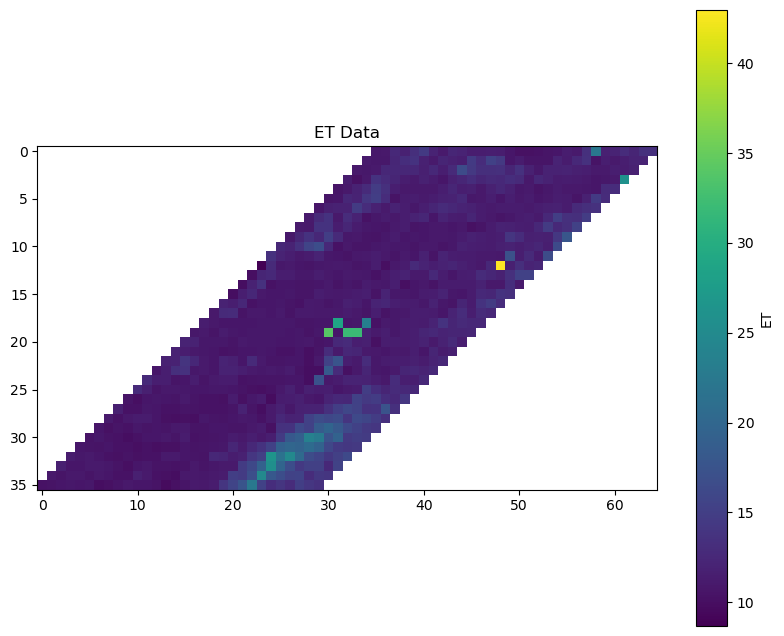

In [157]:
#use this after running the slide above

def find_sd_of_tiffs(list_of_tiffs):
    tiff_data = []

    def get_tiff_data(tiff):
        xds = rioxarray.open_rasterio(tiff)
        tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        tiff = tiff[0, :, :]
        tiff = np.where(tiff >= 32700, np.nan, tiff)
        return tiff

    for tiff in list_of_tiffs:
        #print(np.shape(tiff))
        tiff_data.append(get_tiff_data(tiff))
        #tiff = np.where(tiff >= 32700, np.nan, tiff)

    print(tiff_data)

    sd = tiff_data[0] * 0.0000001
    sum_sq = (tiff_data[0]) * 0.0000001
    sum_reg = tiff_data[0] * 0.0000001

    for tiff in tiff_data:   
        sum_reg += tiff
        
    mean = sum_reg/len(tiff_data)
    
    for tiff in tiff_data:
        sum_sq += (tiff-mean)**2

    #print(sum_sq)
    
    sd = ((sum_sq)/(len(tiff_data)-1))**0.5
    print(sd)

    sd = np.where(sd < 1, np.nan, sd)

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10,8))
    plt.imshow(sd)
    plt.colorbar(label='ET')
    plt.title('ET Data')
    return plt.show()

find_sd_of_tiffs(list_of_tiffs)

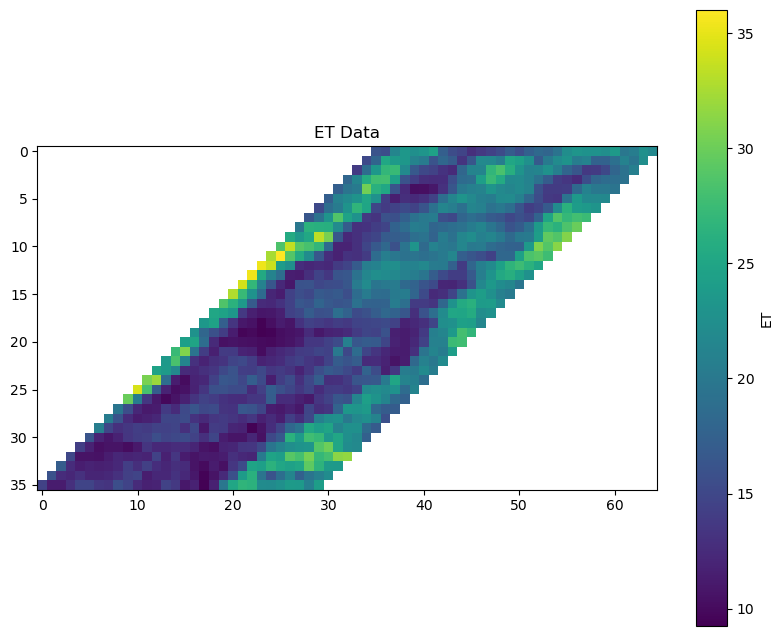

TypeError: invalid dtype: 'object'

In [183]:
test_data = model.generate_et_tiffs(2021, 7, 1, 2021, 7, 31)
test_data += model.generate_et_tiffs(2022, 7, 1, 2022, 7, 31)
test_data += model.generate_et_tiffs(2023, 7, 1, 2023, 7, 31)
test_data += model.generate_et_tiffs(2024, 7, 1, 2024, 7, 31)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
et_test = model.generate_threshold_modis(coords, test_data, 0, 10000)
et_test

import xarray as xr

# If you manually built et_test from numpy:
et_test = xr.DataArray(
    data=et_test,  # the final combined data
    dims=("band", "y", "x"),
    coords={
        "band": [1],
        "y": ref.y,
        "x": ref.x
    },
    attrs=ref.attrs
)

# Now attach the rioxarray metadata
et_test.rio.write_crs(ref.rio.crs, inplace=True)
et_test.rio.write_transform(ref.rio.transform(), inplace=True)

# Save
et_test.rio.to_raster("/Users/ryanjoshi/Downloads/et_test.tif")

#et_test.rio.to_raster("/Users/ryanjoshi/Downloads/et_test.tif")

#import rioxarray
#ref = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024209000000_aid0001.tif')

# Assign spatial metadata from the reference
#et_test.rio.write_crs(ref.rio.crs, inplace=True)
#et_test.rio.write_transform(ref.rio.transform(), inplace=True)

# Now save it
#et_test.rio.to_raster("/Users/ryanjoshi/Downloads/et_test.tif")

[array([[nan, nan, nan, ..., 32., 34., 34.],
       [nan, nan, nan, ..., 34., 36., nan],
       [nan, nan, nan, ..., 34., nan, nan],
       ...,
       [nan, nan, 38., ..., nan, nan, nan],
       [nan, 32., 30., ..., nan, nan, nan],
       [31., 30., 30., ..., nan, nan, nan]], shape=(36, 65)), array([[nan, nan, nan, ..., 25., 27., 31.],
       [nan, nan, nan, ..., 27., 31., nan],
       [nan, nan, nan, ..., 24., nan, nan],
       ...,
       [nan, nan, 39., ..., nan, nan, nan],
       [nan, 38., 28., ..., nan, nan, nan],
       [31., 24., 24., ..., nan, nan, nan]], shape=(36, 65)), array([[nan, nan, nan, ..., 37., 38., 27.],
       [nan, nan, nan, ..., 38., 45., nan],
       [nan, nan, nan, ..., 45., nan, nan],
       ...,
       [nan, nan, 41., ..., nan, nan, nan],
       [nan, 41., 23., ..., nan, nan, nan],
       [36., 17., 18., ..., nan, nan, nan]], shape=(36, 65)), array([[nan, nan, nan, ..., 72., 51., 44.],
       [nan, nan, nan, ..., 49., 51., nan],
       [nan, nan, nan, ..., 5

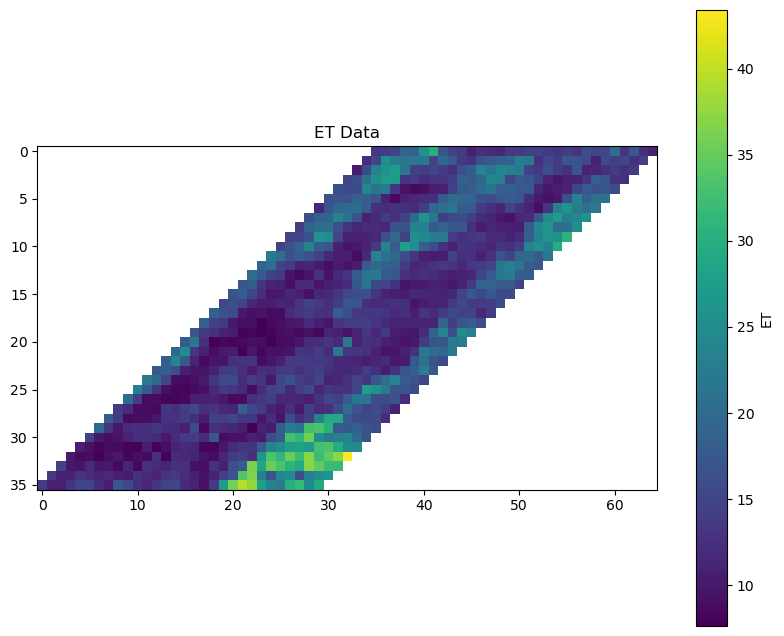

AttributeError: 'NoneType' object has no attribute 'rasterio'

In [168]:
test_sds = find_sd_of_tiffs(test_data)
test_sds.rasterio.to_raster("/Users/ryanjoshi/Downloads/nm_test_sds.tif")

(1526, 1347)


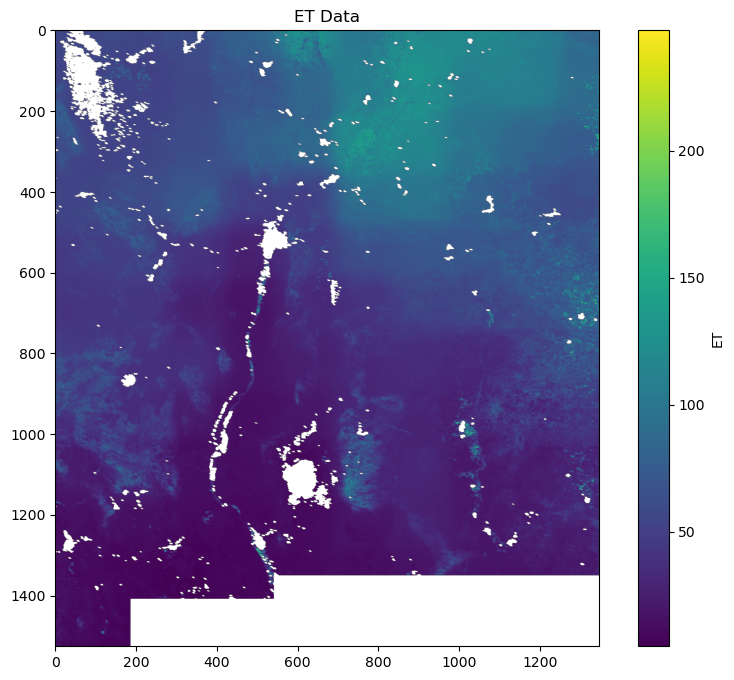

AttributeError: 'numpy.ndarray' object has no attribute 'rio'

In [195]:
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                 [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)

if new_mexico.shape[0] == 1:
    new_mexico = new_mexico[0, :, :]

print(new_mexico.shape)
new_mexico.ndim

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

import xarray as xr
import rioxarray

# If you manually built et_test from numpy:
'''new_mexico = xr.DataArray(
    data=new_mexico,  # the final combined data
    dims=("y", "x"),
    coords={
        #"band": [1],
        "y": ref.y,
        "x": ref.x
    },
    attrs=ref.attrs
)
#new_mexico = new_mexico[0,:,:]'''

# Now attach the rioxarray metadata
new_mexico.rio.write_crs(ref.rio.crs, inplace=True)
new_mexico.rio.write_transform(ref.rio.transform(), inplace=True)

# Save
new_mexico.rio.to_raster("/Users/ryanjoshi/Downloads/test_download_may_first.tif")